# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [4]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

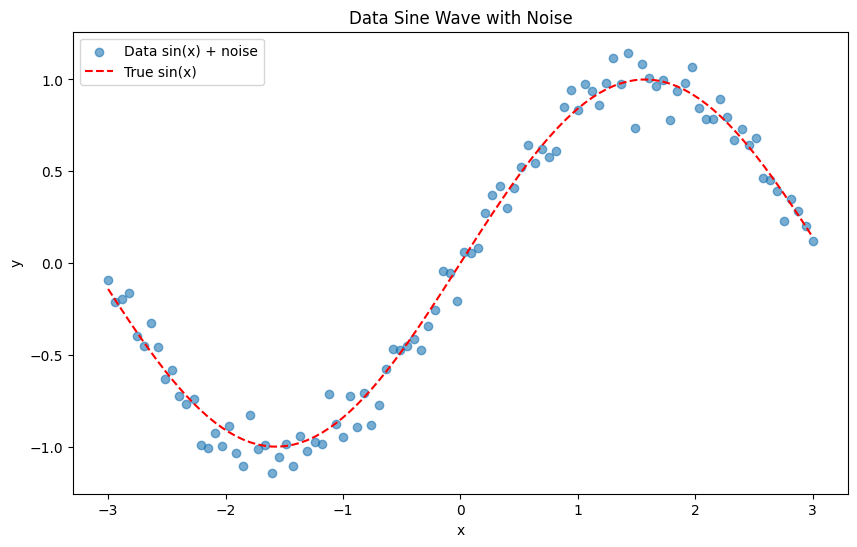

Started with w =  -0.7076853710252071  b=   -0.21032266138267952
It ended with w =  0.33903284338492196  and b =  -0.010384651739409443
the final loss was  0.1954517971396205


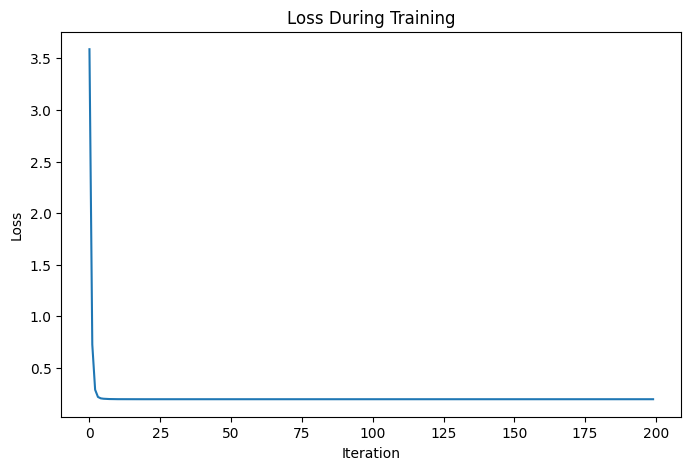

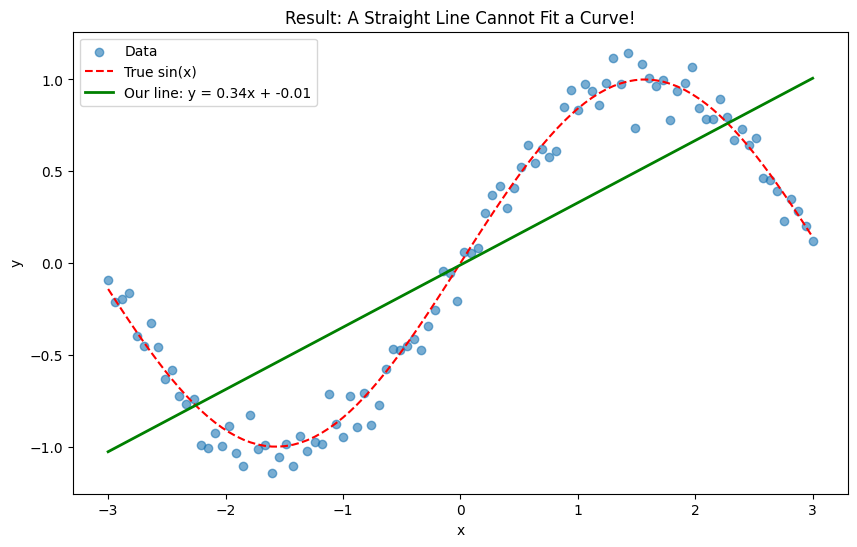

In [5]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=100)
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Data sin(x) + noise')
plt.plot(x, np.sin(x), 'r--', label='True sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Data Sine Wave with Noise')
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5

print("Started with w = ", w , " b=  ", b)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
learning_r = 0.1
losses = []
for step in range(200):
  y_hat = w*x+b
  loss = np.mean((y_hat-y)**2)
  losses.append(loss)
  dw = np.mean(2*(y_hat-y)*x)
  db = np.mean(2*(y_hat-y))
  w-= learning_r*dw
  b-=learning_r*db
print("It ended with w = ",w," and b = ", b)
print("the final loss was ",losses[-1])

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss During Training")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x, np.sin(x), 'r--', label='True sin(x)')
plt.plot(x, w * x + b, 'g-', linewidth=2, label=f'Our line: y = {w:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Result: A Straight Line Cannot Fit a Curve!')
plt.show()



#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 2. It is underfitting, the y hat is a straight line, meaning no matter how long we train the w and b the straight line would not be able to get the shape of the curve, and it stops improving because the model ends up finding the line that reduces the error but that line is wrong, but because of the parameters given it cannot get the shape of the function

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final loss:  0.012595561457881013


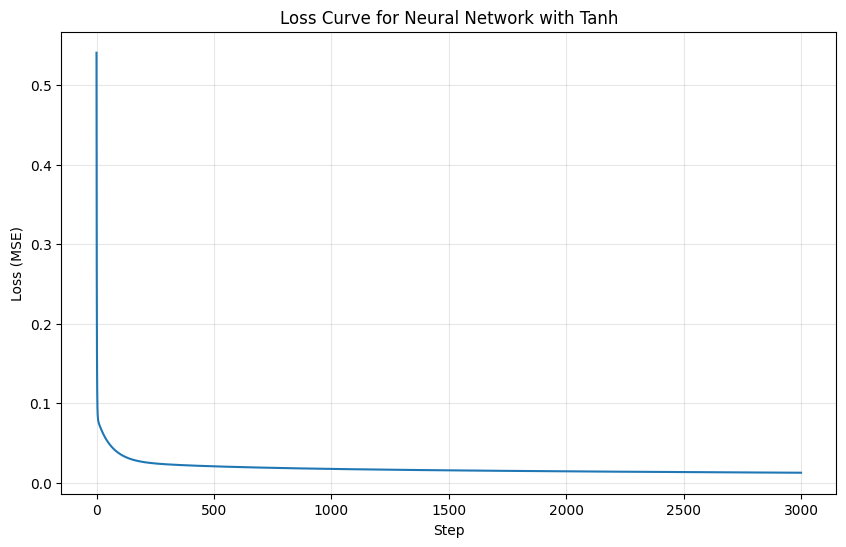

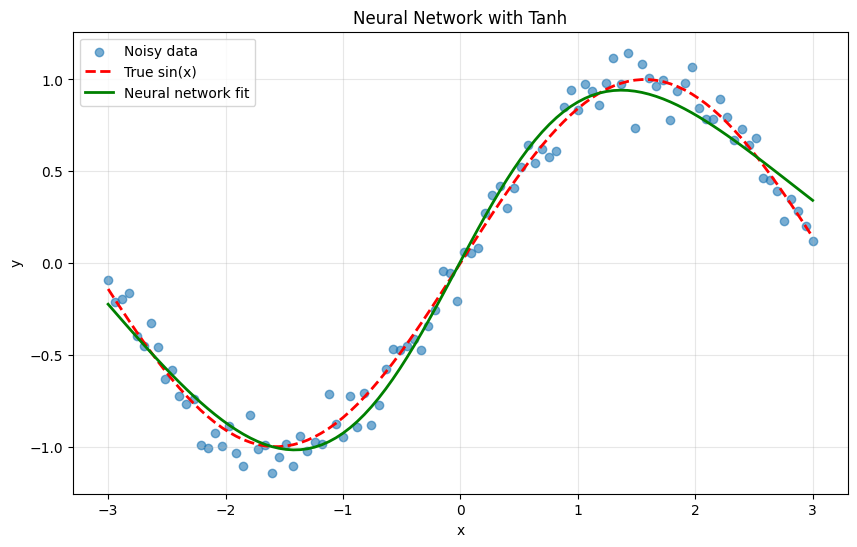

Final loss without tanh:   0.19545179713962046


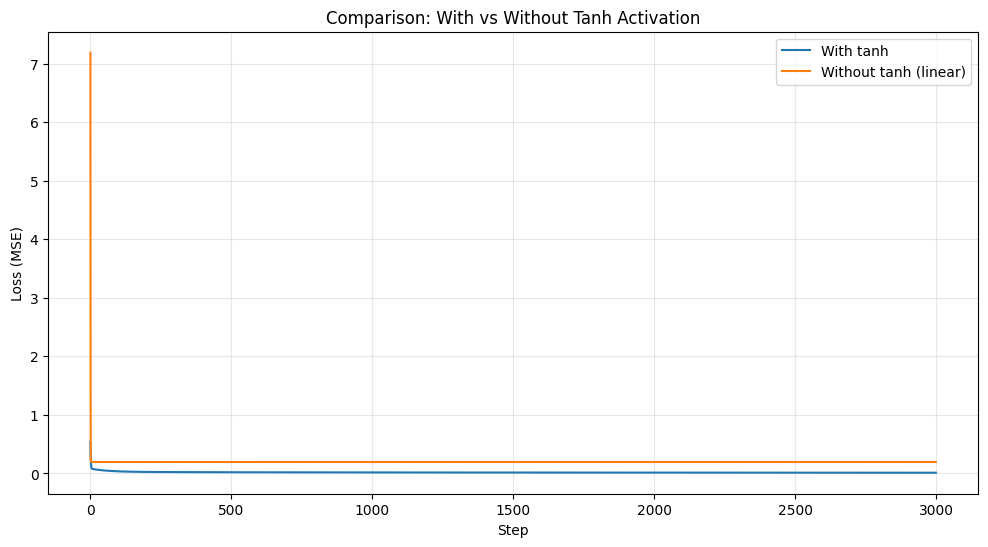

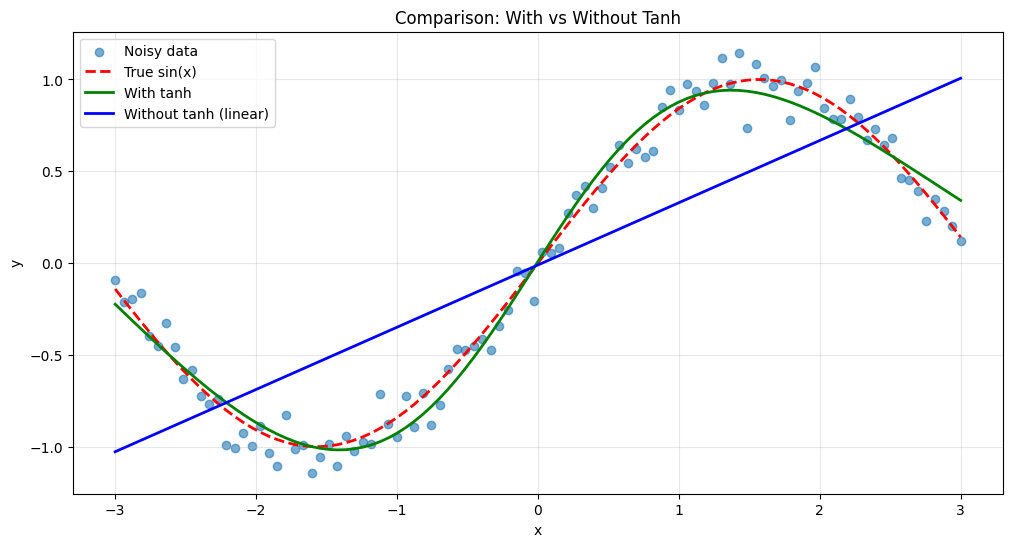

In [6]:
# TODO: Initialise parameters
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=100)
W1= np.random.randn(1,8)*0.5
b1= np.random.randn(8)*0.5
W2= np.random.randn(8,1) *0.5
b2 = np.random.randn(1)*0.5





#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
learning_r=0.05
losses =[]
for step in range(3000):
  z1 = x.reshape(-1,1) @ W1+b1
  h= np.tanh(z1)
  y_hat = h@ W2 +b2

  loss = np.mean((y_hat - y.reshape(-1,1))**2)
  losses.append(loss)

#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
  d_yhat = 2*(y_hat - y.reshape(-1,1)) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.reshape(-1, 1).T @ dz1
  db1 = dz1.sum(axis=0)
  W1-= learning_r*dW1
  b1-= learning_r*db1
  W2-= learning_r*dW2
  b2-= learning_r*db2
print("Final loss: ", losses[-1])
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss (MSE)')
plt.title('Loss Curve for Neural Network with Tanh')
plt.grid(True, alpha=0.3)
plt.show()

y_pred = np.tanh(x.reshape(-1,1)@W1+b1)@W2 +b2

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Noisy data')
plt.plot(x, np.sin(x), 'r--', linewidth=2, label='True sin(x)')
plt.plot(x, y_pred, 'g-', linewidth=2, label='Neural network fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Neural Network with Tanh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()






#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

np.random.seed(42)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5
losses_linear = []
for step in range(3000):
  z1 = x.reshape(-1,1) @W1 +b1
  h = z1
  y_hat = h@W2 +b2
  loss = np.mean((y_hat-y.reshape(-1,1))**2)
  losses_linear.append(loss)

  d_yhat = 2*(y_hat - y.reshape(-1,1))/len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ W2.T
  dz1 = dh
  dW1 = x.reshape(-1, 1).T @ dz1
  db1 = dz1.sum(axis=0)
  W1 -= learning_r * dW1
  b1 -= learning_r * db1
  W2 -= learning_r * dW2
  b2 -= learning_r * db2
print("Final loss without tanh:  ", losses_linear[-1])

plt.figure(figsize=(12, 6))
plt.plot(losses, label='With tanh')
plt.plot(losses_linear, label='Without tanh (linear)')
plt.xlabel('Step')
plt.ylabel('Loss (MSE)')
plt.title('Comparison: With vs Without Tanh Activation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

y_pred_linear = (x.reshape(-1, 1) @ W1 + b1) @ W2 + b2

plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.6, label='Noisy data')
plt.plot(x, np.sin(x), 'r--', linewidth=2, label='True sin(x)')
plt.plot(x, y_pred, 'g-', linewidth=2, label='With tanh')
plt.plot(x, y_pred_linear, 'b-', linewidth=2, label='Without tanh (linear)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison: With vs Without Tanh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 2. The hidden neurons help with tanh activation, each of them bends the line and together they help approximate the sine curve

3.backpropagation efficiently finds the gradient of a loss in respect to all the parameters by using the chain rule backwards through the network

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

Training by different learning rates
 learning_r =  0.001  final loss =  0.046774916228919626
 learning_r =  0.05  final loss =  0.012595561457881013


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_465/3026073294.py:19: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_465/3026073294.py:25: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_465/3026073294.py:26: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


 learning_r =  1.0  final loss =  nan


/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


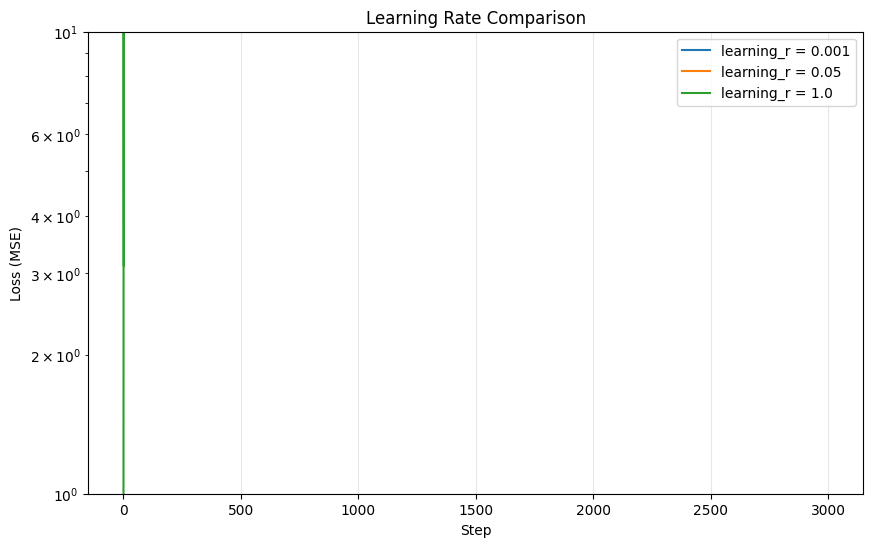

In [7]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(learning_r, steps=3000):
  np.random.seed(42)
  x = np.linspace(-3, 3, 100)
  y = np.sin(x) + np.random.normal(0, 0.1, 100)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.random.randn(1) * 0.5
  x = x.reshape(-1, 1)
  y = y.reshape(-1, 1)
  losses =[]

  for step in range(steps):
    z1 = x @ W1 +b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)
    W1 -= learning_r * dW1
    b1 -= learning_r * db1
    W2 -= learning_r * dW2
    b2 -= learning_r * db2
  return losses
learning_rates = [0.001,0.05,1.0]
results ={}

print("Training by different learning rates")
for learning_r in learning_rates:
  losses = train_toy(learning_r,steps=3000)
  results[learning_r]=losses
  print(" learning_r = ", learning_r, " final loss = ", losses[-1])
plt.figure(figsize=(10,6))
for learning_r,losses in results.items():
  plt.plot(losses,label=f'learning_r = {learning_r}')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Loss (MSE)')
plt.title('Learning Rate Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()







# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [8]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)
print(f"Dataset shape: {obesity.shape}")

from sklearn.preprocessing import LabelEncoder

obesity_clean = obesity.copy()
for col in ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]:
    obesity_clean[col] = obesity_clean[col].map({'yes': 1, 'no': 0})
obesity_encoded = pd.get_dummies(
    obesity_clean,
    columns=['Gender', 'CAEC', 'CALC', 'MTRANS'],
    drop_first=True
)
le = LabelEncoder()
y_obesity = le.fit_transform(obesity_clean['NObeyesdad'])
X_obesity = obesity_encoded.drop('NObeyesdad', axis=1)

print(f"X shape: {X_obesity.shape}, y shape: {y_obesity.shape}")
print(f"Classes: {le.classes_}")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_temp, X_test, y_temp, y_test = train_test_split(
    X_obesity, y_obesity,
    test_size=0.2,
    stratify=y_obesity,
    random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Shapes after scaling: ", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape )

import torch
from torch.utils.data import DataLoader, TensorDataset
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)







# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

Dataset shape: (2111, 17)
X shape: (2111, 23), y shape: (2111,)
Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
Shapes after scaling:  (1266, 23) (422, 23) (423, 23)


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 2. Networks use the change in gradient to update the weights, dloss/dw = mean (2*(y_hat-y)*x)
this shows the gradient is multiplied by x, so feautures with higher values will be most affected with change in gradient. This makes the training slow, scaling makes all features equal to the gradient

3. shuffle randomizes the order of training, this helps prevent learning patterns based on the order of data and it also reduces overfitting

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [11]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)  # No softmax (CrossEntropyLoss handles it)
        return x

input_dim = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim, hidden_sizes=(64, 32), n_classes=7)
model = model.to(DEVICE)

print("Model architecture:")
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# ✅ ADD THIS LINE
first_layer_params = input_dim * 64 + 64
print(f"First layer: {input_dim} * 64 + 64 = {first_layer_params:,} parameters")

#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

Model architecture:
FeedForwardNet(
  (fc1): Linear(in_features=23, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=7, bias=True)
)

Total trainable parameters: 3,847
First layer: 23 * 64 + 64 = 1,536 parameters


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 1. layer 1: 24*64 +64 =1600
layer 2 = 64*32+32 =2000
layer 3 = 32*7+7 = 231

2. faster computation
no vanishing gradient



### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

9: Train 0.883 | Val 0.851
19: Train 0.974 | Val 0.929
29: Train 0.991 | Val 0.943
39: Train 0.999 | Val 0.941
49: Train 0.999 | Val 0.948

Best validation accuracy: 0.9479


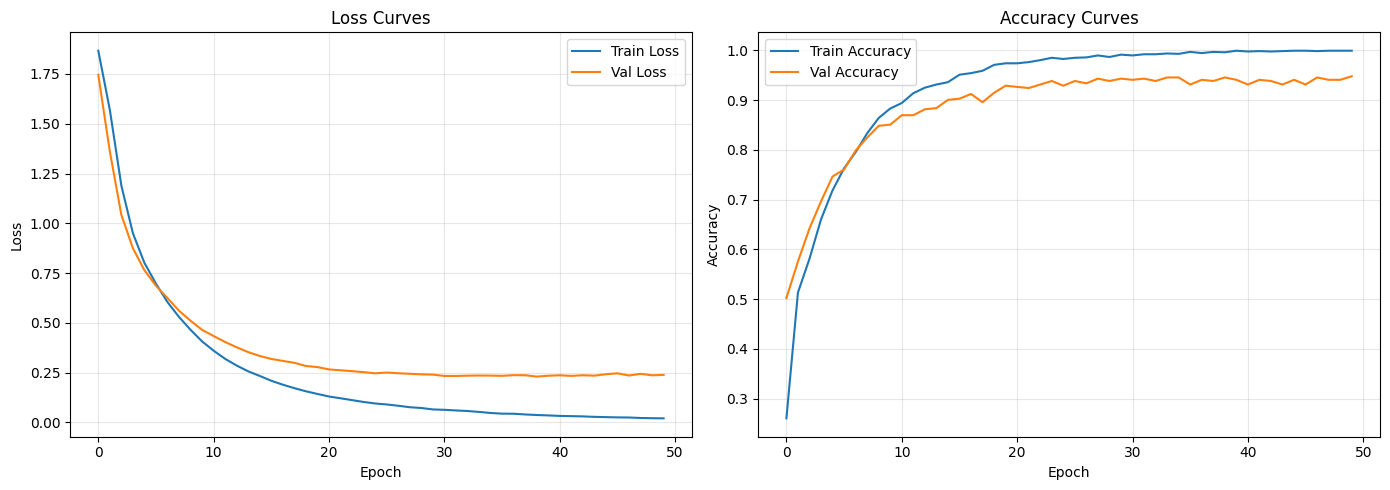

In [15]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Changed learning_r to lr

epochs = 50
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"{epoch}: Train {train_acc:.3f} | Val {val_acc:.3f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# --- PLOT ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** outputs = model(X_batch) -> forward pass
loss.backward -> backward pass
optimizer.step()-> update rule

2. It is overfitting because training accuracy is higher than validation accuracy

3.without it gradients would be added upon each other instead of being overwritten. This would cause a mistake in the model

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.